In [ ]:
import joblib
import pandas as pd

test = pd.read_csv("../data/processed/test_processed.csv")

tfidf = joblib.load(
    "../models/personality_model/tfidf.pkl"
)

In [3]:
traits = ["O", "C", "E", "A", "N"]

X_test = tfidf.transform(
    test["clean_text"]
)

In [ ]:
from sklearn.metrics import classification_report

for trait in traits:

    model = joblib.load(
        f"../models/personality_model/{trait}.pkl"
    )

    pred = model.predict(X_test)

    print(f"\n{'='*50}")
    print(f"Trait: {trait}")
    print(classification_report(
        test[trait],
        pred
    ))


Trait: O
              precision    recall  f1-score   support

           0       0.66      0.59      0.62       239
           1       0.65      0.71      0.68       255

    accuracy                           0.65       494
   macro avg       0.65      0.65      0.65       494
weighted avg       0.65      0.65      0.65       494


Trait: C
              precision    recall  f1-score   support

           0       0.56      0.51      0.54       244
           1       0.56      0.61      0.58       250

    accuracy                           0.56       494
   macro avg       0.56      0.56      0.56       494
weighted avg       0.56      0.56      0.56       494


Trait: E
              precision    recall  f1-score   support

           0       0.56      0.48      0.52       239
           1       0.57      0.65      0.61       255

    accuracy                           0.57       494
   macro avg       0.57      0.57      0.56       494
weighted avg       0.57      0.57      0.57 

In [4]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    test["E"],
    pred
)

print(cm)

[[127 112]
 [129 126]]


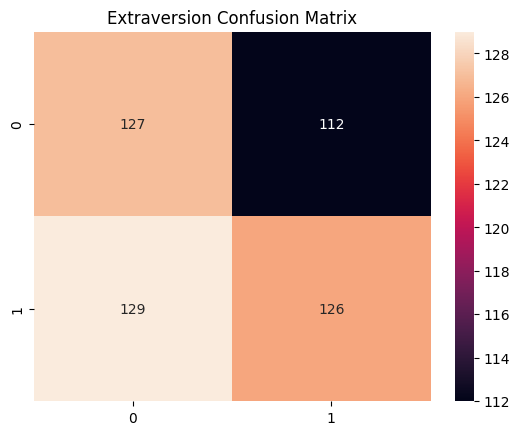

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
    "Extraversion Confusion Matrix"
)

plt.show()

In [10]:
errors = test.copy()

errors["pred_E"] = pred

errors = errors[
    errors["pred_E"] != errors["E"]
]

errors.head()

,O,C,E,A,N,ptype,text,__index_level_0__,clean_text,pred_E
1,0,0,0,1,1,3,I'm kind of frustrated right now with Callie. ...,821,im kind frustrated right callie left go meetin...,1
5,1,0,0,1,0,18,"How do I feel? Well each day is different, so...",966,feel well day different sometimes overjoyed ex...,1
6,0,1,0,0,1,9,My room is so dark and cold right now. I ...,1673,room dark cold right wish roommate didnt like ...,1
7,1,0,1,0,0,20,Aug. 31 Note: I wrote this paper over a week ...,106,aug note wrote paper week ago typing said coul...,0
8,1,1,0,0,0,24,As soon as I am done with this I plan to ...,1737,soon done plan go friend maybe gym dont really...,1
